# Pololu Controller Navigation Environment Test
Integration test: Pololu controller inside navigation gym environment with visualization

In [1]:
import numpy as np
import time
import sys

sys.path.insert(0, '..')

from tools.envs.navigation_envs.navigation_env_pololu import NavigationEnvPololu

Successfully registered NavigationEnvBrokenRudder-v0


## Create Environment
Set up the Pololu navigation environment with rendering enabled

In [2]:
# Deterministic setup
env = NavigationEnvPololu(dt=1.0, sparse_reward=False, obstacle_mode="none", render_mode="human", render_sleep=0.02)
obs, info = env.reset(seed=0)

# Remove any randomly created obstacles for a clean test track
if hasattr(env, "obstacles"):
    env.obstacles = []

# Disable truncation checks (collision/time) to focus on controller tracking
env.is_truncated = lambda state: False

print("Environment created successfully")
print(f"Initial agent state: {env.agent.state}")
print(f"dt: {env.dt}")

INFO:tools.envs.navigation_envs.navigation_env:---- Starting Initialization of NavigationEnv
/Users/christoph/Library/CloudStorage/SynologyDrive-Documents_Sync/research/projects/ann-cmcgs/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/christoph/Library/CloudStorage/SynologyDrive-Documents_Sync/research/projects/ann-cmcgs/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
INFO:tools.envs.navigation_envs.navigation_env:---- Finished Initialization of NavigationEnv
INFO:tools.robots.single_integrator_unicycle:Starting initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle:Finished initialization of SingleIntegratorUnicycle
INFO:tools.robots.single_integrator_unicycle_space:Starting initializa

---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycleSpace
---- Starting Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
Starting initialization of SingleIntegrator
Finished initialization of SingleIntegrator
---- Finished Initialization of NavigationEnvSingleIntegratorUnicycle
---- NavigationEnvSingleIntegratorUnicycle reset called with seed: 0 and options: None
start_obs: [0. 3. 0. 0. 9. 4.] goal_obs: [ 9.  4. nan nan  9.  4.]
Environment created successfully
Initial agent state: [0. 3. 0. 0.]
dt: 1.0


## Set Goal and Compute Controller Actions
Place robot at origin facing +x with goal at (1, 0)

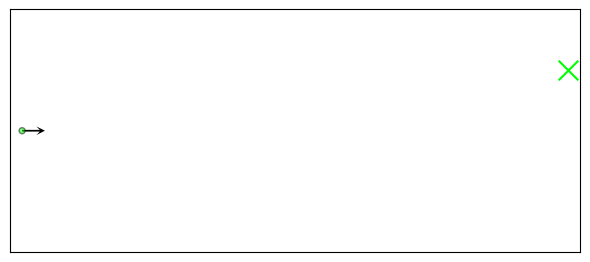

<Figure size 1200x1200 with 0 Axes>

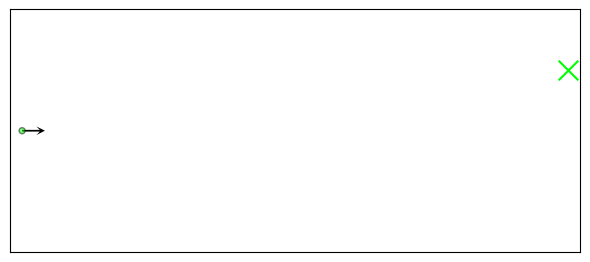

In [ ]:
# Place robot at origin, facing +x; set a simple goal at (1, 0)
env._max_episode_steps = 4

# Build setpoint state: [x, y, theta, t]
target_theta = -0.0
setpoint_state = np.array([
    env.goal_pos[0],
    env.goal_pos[1],
    target_theta,
], dtype=np.float32)

print(f"Robot initial state: {env.agent.state}")
print(f"Goal position: {env.goal_pos}")
print(f"Setpoint state (target): {setpoint_state}")
env.render()

## Run Pololu Controller
Generate control actions to reach the goal

In [4]:
# Run controller to generate actions
action_list, dt_list = env.agent.controller_pololu(
    env.agent.state, setpoint_state, N=10
)

print(f"Number of actions generated: {len(action_list)}")
print(f"Sample actions (first 3):")
for i in range(min(3, len(action_list))):
    print(f"  Step {i}: action={action_list[i]}, dt={dt_list[i]:.3f}")

Number of actions generated: 10
Sample actions (first 3):
  Step 0: action=[1.         0.08565357], dt=0.100
  Step 1: action=[1.         0.04119018], dt=0.100
  Step 2: action=[1.         0.02044098], dt=0.100


## Execute Actions in Environment
Apply controller actions and render the trajectory

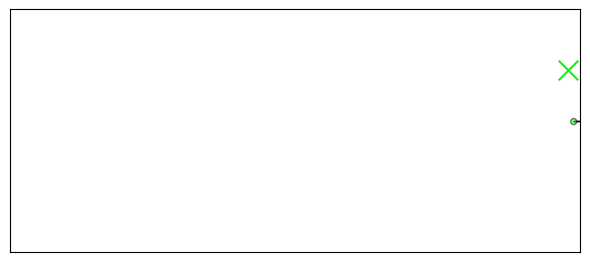

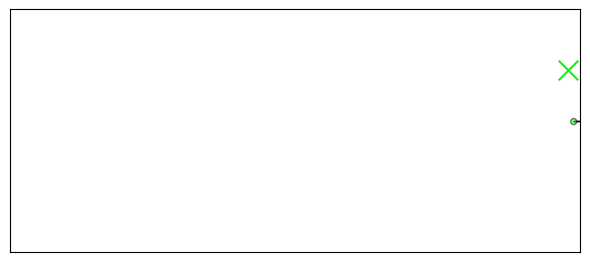

Step 10: state=[9.096657   3.15104    0.01689219], reward=0.0100

Execution complete!
Steps taken: 10
Final agent state: [ 9.096657    3.15104     0.01689219 10.0001335 ]
Total reward accumulated: 0.1000
Terminated: False, Truncated: False


In [5]:
# Apply actions step-by-step with rendering
# Query controller after every step to get updated actions
total_reward = 0.0
step_count = 0
env.reset()
for _ in range(len(action_list)):
    # Get next action from controller
    action_list, dt_list = env.agent.controller_pololu(
        env.agent.state, setpoint_state, N=10
    )

    print(env.agent.state, setpoint_state)
    print(np.array(action_list), np.array(dt_list))
    assert np.isclose(np.sum(dt_list), env.dt), "Time steps do not match env.dt"
    time.sleep(1.5)

    obs, reward, terminated, truncated, info = env.multi_step(action_list, dt_list, render=True)

    time.sleep(0.1)
    total_reward += reward
    step_count += 1
    
    if step_count % 5 == 0:
        print(f"Step {step_count}: state={env.agent.state[:3]}, reward={reward:.4f}")
    
    if terminated or truncated:
        break

print(f"\nExecution complete!")
print(f"Steps taken: {step_count}")
print(f"Final agent state: {env.agent.state}")
print(f"Total reward accumulated: {total_reward:.4f}")
print(f"Terminated: {terminated}, Truncated: {truncated}")

## Validate Goal Reached
Check if the controller successfully reached the goal

In [6]:
# Validate: reached goal (truncation forced off)
is_finished = env.agent.is_finished(env.agent.state, setpoint_state, atol=env.atol, rtol=env.rtol)

print(f"Agent finished (reached goal): {is_finished}")
print(f"\nFinal state: {env.agent.state}")
print(f"Target state: {setpoint_state}")
print(f"Position error: {np.linalg.norm(env.agent.state[:2] - setpoint_state[:2]):.6f}")
print(f"Heading error: {np.abs(env.agent.state[2] - setpoint_state[2]):.6f}")

assert is_finished, f"Agent did not reach goal. Final state: {env.agent.state}, goal: {setpoint_state}"
print("\n✓ Test passed!")

ValueError: not enough values to unpack (expected 4, got 3)

## View Rendered Trajectory
Keep the render window open for 10 seconds

In [ ]:
print("Keeping render window open for 10 seconds...")
time.sleep(10)
env.close()
print("Done!")